In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests
from statannotations.Annotator import Annotator
import itertools

In [2]:
sns.set_theme(style='ticks')

In [3]:
papers_clusters_df = pd.read_csv("clusters_papers.csv", index_col='PatientID', dtype=str)
papers_clusters_df

,My Clusters,bailey,collisson,copy_number,incrna,moffitt,moffitt_highpurity,methyl,methyl_highpurity,mirna,rppa,rppa_highpurity
PatientID,,,,,,,,,,,,
TCGA-2J-AAB6,1,Squamous,QM,Low,1,Basal-like,Basal-like,1,1,1,NaN,NaN
TCGA-2J-AAB8,1,Progenitor,Classical,High,2,Classical,NaN,1,LowPurity,1,NaN,LowPurity
TCGA-2J-AAB9,0,ADEX,Exocrine,Low,1,Basal-like,NaN,NaN,LowPurity,1,NaN,LowPurity
TCGA-2J-AABA,1,Progenitor,Classical,Low,2,Classical,Classical,2,2,1,NaN,NaN
TCGA-2J-AABE,1,Progenitor,Classical,Low,2,Basal-like,Basal-like,2,2,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-XD-AAUL,1,Squamous,Classical,Low,1,Basal-like,Basal-like,2,2,2,1,1
TCGA-XN-A8T3,1,ADEX,Exocrine,Low,1,Basal-like,NaN,2,LowPurity,1,NaN,LowPurity
TCGA-YB-A89D,1,Progenitor,Classical,Low,1,Classical,NaN,2,LowPurity,2,2,LowPurity


In [4]:
from matplotlib import rcParams
sns.set_theme(style='ticks')
rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'axes.edgecolor': 'black',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'legend.fontsize': 12,
    'legend.frameon': False,
    'savefig.format': 'svg',
    'savefig.dpi': 300,  # Still useful for rasterized elements
    'figure.dpi': 100,
    'figure.figsize': (3.5, 2.5),  # Approx. half-column width
    'figure.constrained_layout.use': True,
    'svg.fonttype': 'none',  # Keep text as editable text (not paths)
    'axes.spines.top': False,
    'axes.spines.right': False,
})

bailey general chi-square test result: 1.9835643257284826e-07
Post-hoc 2×2 Fisher's exact tests (FDR corrected):
ADEX vs Immunogenic: raw p=0.7936, corrected p=0.9524 (ns)
ADEX vs Progenitor: raw p=1.865e-06, corrected p=1.119e-05 (*)
ADEX vs Squamous: raw p=5.01e-05, corrected p=0.0001002 (*)
Immunogenic vs Progenitor: raw p=3.605e-05, corrected p=0.0001002 (*)
Immunogenic vs Squamous: raw p=0.0003842, corrected p=0.0005763 (*)
Progenitor vs Squamous: raw p=1, corrected p=1 (ns)

collisson general chi-square test result: 0.00024079699493563035
Post-hoc 2×2 Fisher's exact tests (FDR corrected):
Classical vs Exocrine: raw p=1.609e-05, corrected p=4.827e-05 (*)
Classical vs QM: raw p=0.002504, corrected p=0.003757 (*)
Exocrine vs QM: raw p=0.4437, corrected p=0.4437 (ns)

moffitt general chi-square test result: 1.0
Post-hoc 2×2 Fisher's exact tests (FDR corrected):
Basal-like vs Classical: raw p=1, corrected p=1 (ns)



C:\Users\alepg\AppData\Local\Temp\ipykernel_7068\217385780.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout(w_pad=5)


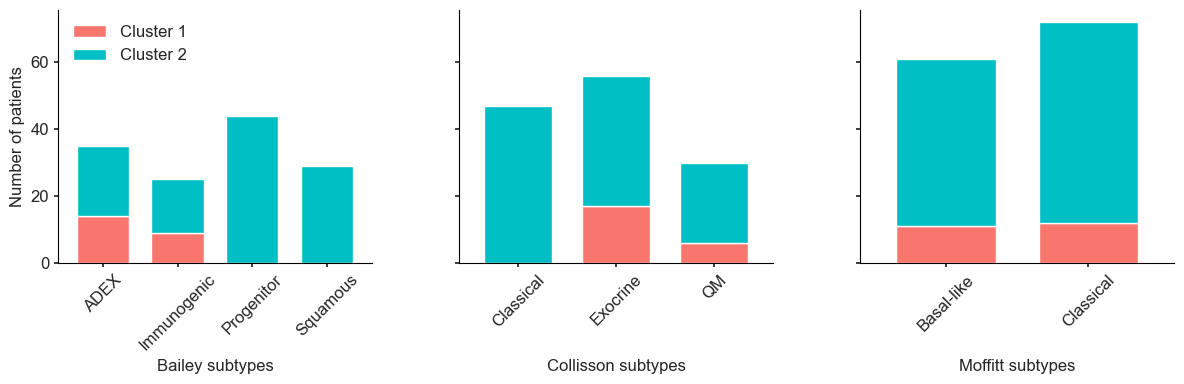

In [5]:
papers = ['bailey', 'collisson', 'moffitt']
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
palette = ["#F8766D", "#00BFC4"]
papers_clusters_df['My Clusters'] = papers_clusters_df['My Clusters'].replace({'0': 'Cluster 1', '1': 'Cluster 2'})
for i, author in enumerate(papers):
    paper_data = papers_clusters_df[['My Clusters', author]]
    cluster_counts = pd.crosstab(paper_data[author], paper_data['My Clusters'])
    chi2, p_value_chi2, dof, freq = chi2_contingency(cluster_counts)
    print(f"{author} general chi-square test result: {p_value_chi2}")
    cluster_counts.plot(kind='bar', stacked=True, ax=ax[i], color=palette, width=0.7)
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
    ax[i].set_ylabel('Number of patients')
    categories = cluster_counts.index.tolist()
    pairwise_pvals = []
    comparisons = []
    for cat1, cat2 in itertools.combinations(categories, 2):
        sub_table = cluster_counts.loc[[cat1, cat2]]
        table_2x2 = sub_table.to_numpy()
        odds_ratio, pval = fisher_exact(table_2x2)
        pairwise_pvals.append(pval)
        comparisons.append((cat1, cat2))
    reject, pvals_corrected, _, _ = multipletests(pairwise_pvals, method='fdr_bh')
    print("Post-hoc 2×2 Fisher's exact tests (FDR corrected):")
    for (cat1, cat2), pval, corr_pval, sig in zip(comparisons, pairwise_pvals, pvals_corrected, reject):
        sig_marker = "*" if sig else "ns"
        print(f"{cat1} vs {cat2}: raw p={pval:.4g}, corrected p={corr_pval:.4g} ({sig_marker})")
    print('')
ax[0].set_xlabel('Bailey subtypes')
ax[1].set_xlabel('Collisson subtypes')
ax[2].set_xlabel('Moffitt subtypes')
fig.align_labels()
ax[0].legend(loc='upper left')
ax[1].get_legend().remove()
ax[2].get_legend().remove()
plt.tight_layout(w_pad=5)
# plt.savefig('figures/cluster_comparison.svg', bbox_inches='tight')
plt.show()

bailey general chi-square test result: 1.9835643257284826e-07
collisson general chi-square test result: 0.00024079699493563035
moffitt general chi-square test result: 1.0


C:\Users\alepg\AppData\Local\Temp\ipykernel_7068\3527992399.py:63: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


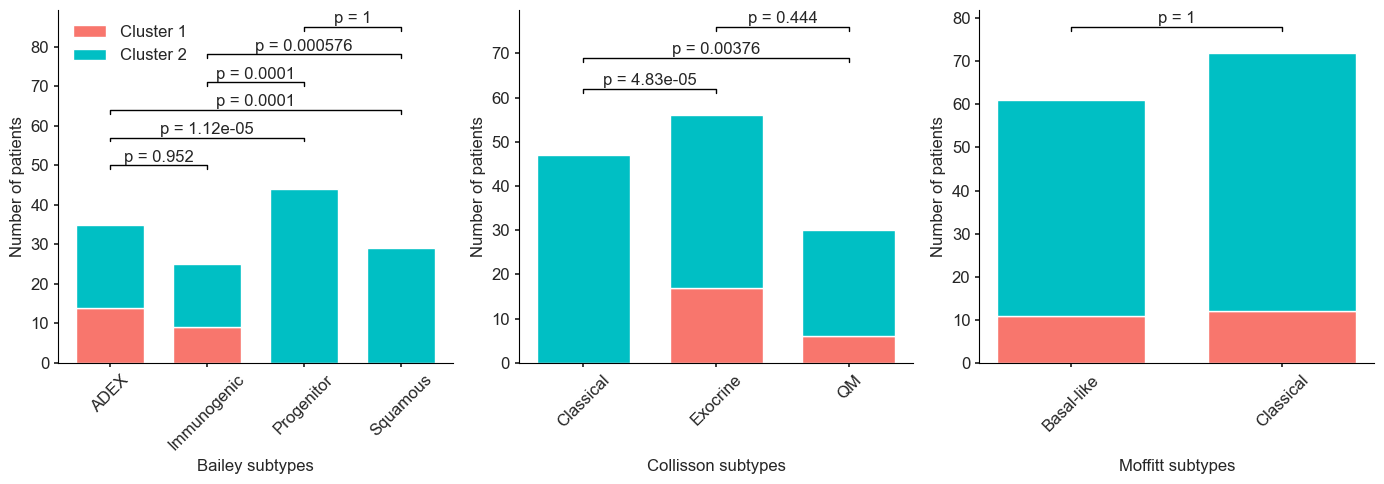

In [6]:
import numpy as np
import itertools
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

papers = ['bailey', 'collisson', 'moffitt']
palette = ["#F8766D", "#00BFC4"]

fig, ax = plt.subplots(1, 3, figsize=(14, 5))

papers_clusters_df['My Clusters'] = papers_clusters_df['My Clusters'].replace({'0': 'Cluster 1', '1': 'Cluster 2'})

def add_stat_bracket(ax, x1, x2, y, h, text, fontsize=12, line_width=1, line_color='black'):
    lx, rx = x1, x2
    ly = y
    rh = y + h
    ax.plot([lx, lx, rx, rx], [ly, rh, rh, ly], lw=line_width, c=line_color)
    ax.text((lx+rx)/2, rh + h*0.1, text, ha='center', va='bottom', fontsize=fontsize)

for i, author in enumerate(papers):
    paper_data = papers_clusters_df[['My Clusters', author]]
    cluster_counts = pd.crosstab(paper_data[author], paper_data['My Clusters'])
    cluster_counts = cluster_counts[['Cluster 1', 'Cluster 2']]
    chi2, p_value_chi2, dof, freq = chi2_contingency(cluster_counts)
    print(f"{author} general chi-square test result: {p_value_chi2}")
    categories = cluster_counts.index.tolist()
    clusters = cluster_counts.columns.tolist()
    x = np.arange(len(categories))
    bar_width = 0.7
    bottom = np.zeros(len(categories))
    for idx, cluster in enumerate(clusters):
        counts = cluster_counts[cluster].values
        ax[i].bar(x, counts, width=bar_width, bottom=bottom, label=cluster, color=palette[idx])
        bottom += counts
    ax[i].set_xticks(x)
    ax[i].set_xticklabels(categories, rotation=45)
    ax[i].set_ylabel('Number of patients')
    pairwise_pvals = []
    comparisons = []
    for cat1, cat2 in itertools.combinations(categories, 2):
        sub_table = cluster_counts.loc[[cat1, cat2]]
        table_2x2 = sub_table.to_numpy()
        odds_ratio, pval = fisher_exact(table_2x2)
        pairwise_pvals.append(pval)
        comparisons.append((cat1, cat2))
    reject, pvals_corrected, _, _ = multipletests(pairwise_pvals, method='fdr_bh')
    y_start = bottom.max() + 5  # start a bit above highest bar
    h = 1  # bracket height
    step = 7  # vertical spacing between brackets
    cat_to_x = {cat: pos for cat, pos in zip(categories, x)}
    for j, ((cat1, cat2), corr_pval) in enumerate(zip(comparisons, pvals_corrected)):
        x1 = cat_to_x[cat1]
        x2 = cat_to_x[cat2]
        y = y_start + j * step
        p_text = f"p = {corr_pval:.3g}"
        add_stat_bracket(ax[i], x1, x2, y, h, p_text)
ax[0].set_xlabel('Bailey subtypes')
ax[1].set_xlabel('Collisson subtypes')
ax[2].set_xlabel('Moffitt subtypes')
fig.align_labels()
ax[0].legend(loc='upper left')
plt.tight_layout()
plt.savefig('FIGURES/final_clusters/cluster_comparison.svg', bbox_inches='tight')
plt.show()